# **KLASIFIKASI KEMISKINAN DI ACEH MENGGUNAKAN ALGORITMA KNN DAN DECISION TREE**

# IMPORT LIBRARY

In [31]:
import numpy as np
import pandas as pd
!pip install scikit-learn --upgrade

#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler

#DECISION TREE
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text, plot_tree

#EVALUASI DAN VALIDASI
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, mean_squared_error
)

#VISUALISASI
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATA

In [32]:
data_mentah = pd.read_excel('/content/data/knn & decision tree (2).xlsx',sheet_name='ACEH 2024')
data_mentah.head()

,Kabupaten/Kota,GARIS KEMISKINAN (RP),IPM,RLS,INDEKS KEDALAMAN KEMISKINAN,LABEL,AKSES SANITASI (%),PENGELUARAN PER KAPITA (RP),TPT (%),TPAK (%),PDRB
0,SIMEULUE,576505,69.01,9.89,2.62,RENTAN,76.51,8106,5.50,71.08,3150
1,ACEH SINGKIL,609322,70.75,8.72,3.06,AMAN,63.22,9862,6.44,57.82,3441
2,ACEH SELATAN,528243,69.10,8.92,1.57,RENTAN,77.96,9190,4.56,59.24,7466
3,ACEH TENGGARA,496074,71.70,10.10,1.64,RENTAN,64.01,8876,4.79,70.51,6737
4,ACEH TIMUR,557943,69.87,8.48,2.04,RENTAN,73.59,9889,7.75,60.84,14935


In [33]:
data_mentah.describe()

,GARIS KEMISKINAN (RP),IPM,RLS,INDEKS KEDALAMAN KEMISKINAN,AKSES SANITASI (%),PENGELUARAN PER KAPITA (RP),TPT (%),TPAK (%),PDRB
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,581894.956522,73.462174,9.743043,2.183478,80.126957,10785.173913,5.300435,66.393478,10413.086957
std,84776.305740,4.413278,1.141691,0.654402,12.967609,2111.646184,1.874842,6.951589,7528.927697
min,473719.000000,68.040000,8.430000,0.710000,49.790000,8106.000000,2.200000,57.820000,1861.000000
25%,525457.000000,70.310000,8.970000,1.665000,71.490000,9526.000000,3.880000,60.365000,4165.000000
50%,576505.000000,72.310000,9.590000,2.120000,82.310000,10150.000000,5.220000,65.070000,7466.000000
75%,608219.500000,75.145000,10.115000,2.770000,89.145000,11539.500000,6.915000,70.135000,14299.500000
max,862944.000000,87.170000,13.100000,3.140000,99.390000,18100.000000,8.470000,83.820000,30100.000000


In [34]:
data_mentah.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Kabupaten/Kota               23 non-null     object 
 1   GARIS KEMISKINAN (RP)        23 non-null     int64  
 2   IPM                          23 non-null     float64
 3   RLS                          23 non-null     float64
 4   INDEKS KEDALAMAN KEMISKINAN  23 non-null     float64
 5   LABEL                        23 non-null     object 
 6   AKSES SANITASI (%)           23 non-null     float64
 7   PENGELUARAN PER KAPITA (RP)  23 non-null     int64  
 8   TPT (%)                      23 non-null     float64
 9   TPAK (%)                     23 non-null     float64
 10  PDRB                         23 non-null     int64  
dtypes: float64(6), int64(3), object(2)
memory usage: 2.1+ KB


# CLEANING DATA

In [35]:
# Cek nilai kosong
print('🔍 Missing Values:')
print(data_mentah.isnull().sum())
print()
print('🏷️ Distribusi:')
print(data_mentah.value_counts())

🔍 Missing Values:
Kabupaten/Kota                 0
GARIS KEMISKINAN (RP)          0
IPM                            0
RLS                            0
INDEKS KEDALAMAN KEMISKINAN    0
LABEL                          0
AKSES SANITASI (%)             0
PENGELUARAN PER KAPITA (RP)    0
TPT (%)                        0
TPAK (%)                       0
PDRB                           0
dtype: int64

🏷️ Distribusi:
Kabupaten/Kota   GARIS KEMISKINAN (RP)  IPM    RLS    INDEKS KEDALAMAN KEMISKINAN  LABEL   AKSES SANITASI (%)  PENGELUARAN PER KAPITA (RP)  TPT (%)  TPAK (%)  PDRB 
ACEH BARAT       644009                 73.69  9.99   3.02                         AMAN    91.09               10548                        5.58     60.23     14050    1
ACEH BARAT DAYA  516947                 68.75  8.78   2.31                         RENTAN  69.39               9559                         3.83     60.50     5367     1
ACEH BESAR       586860                 75.13  10.37  1.88                         RE

# VISUALISAI STATISTIK DESKRIPTIF

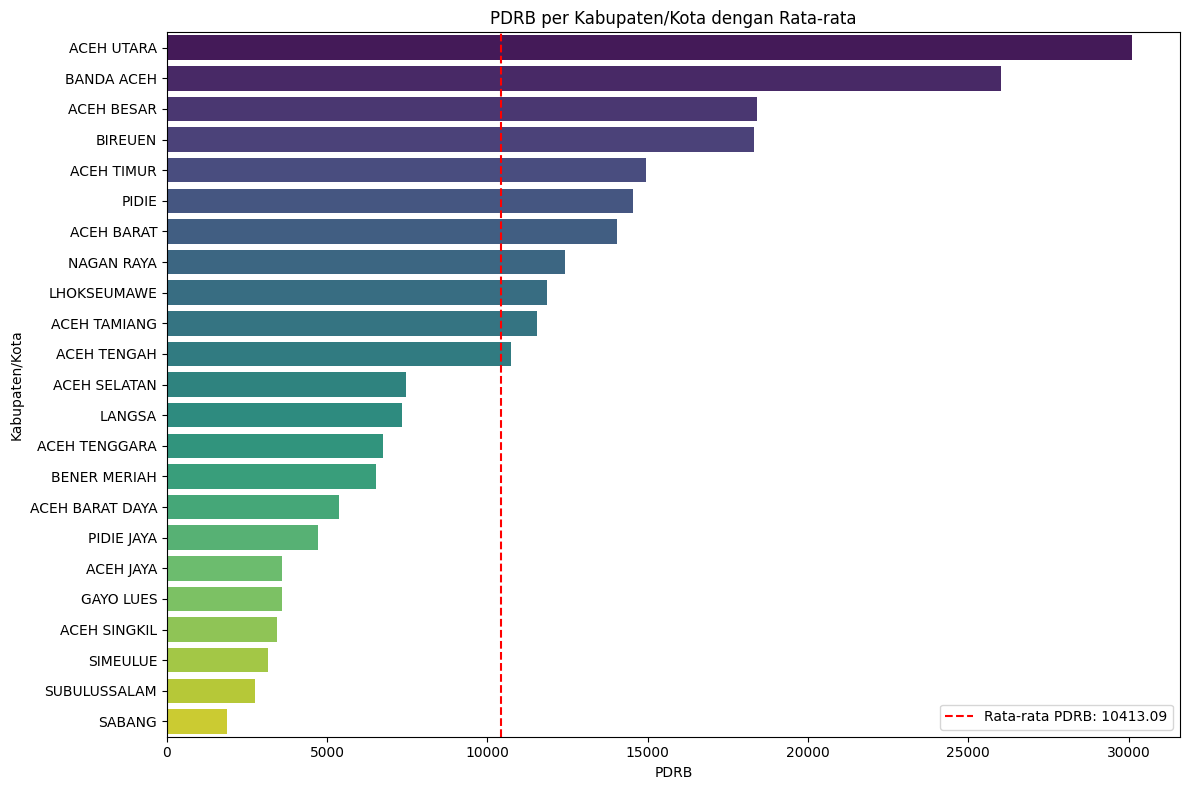

In [36]:
plt.figure(figsize=(12, 8))
data_sorted = data_mentah.sort_values('PDRB', ascending=False)

sns.barplot(
    x='PDRB',
    y='Kabupaten/Kota',
    data=data_sorted,
    hue='Kabupaten/Kota',
    palette='viridis',
    legend=False
)

mean_pdrb = data_mentah['PDRB'].mean()


plt.axvline(x=mean_pdrb, color='red', linestyle='--', label=f'Rata-rata PDRB: {mean_pdrb:.2f}')

plt.xlabel('PDRB')
plt.ylabel('Kabupaten/Kota')
plt.title('PDRB per Kabupaten/Kota dengan Rata-rata')
plt.legend()
plt.tight_layout()
plt.show()

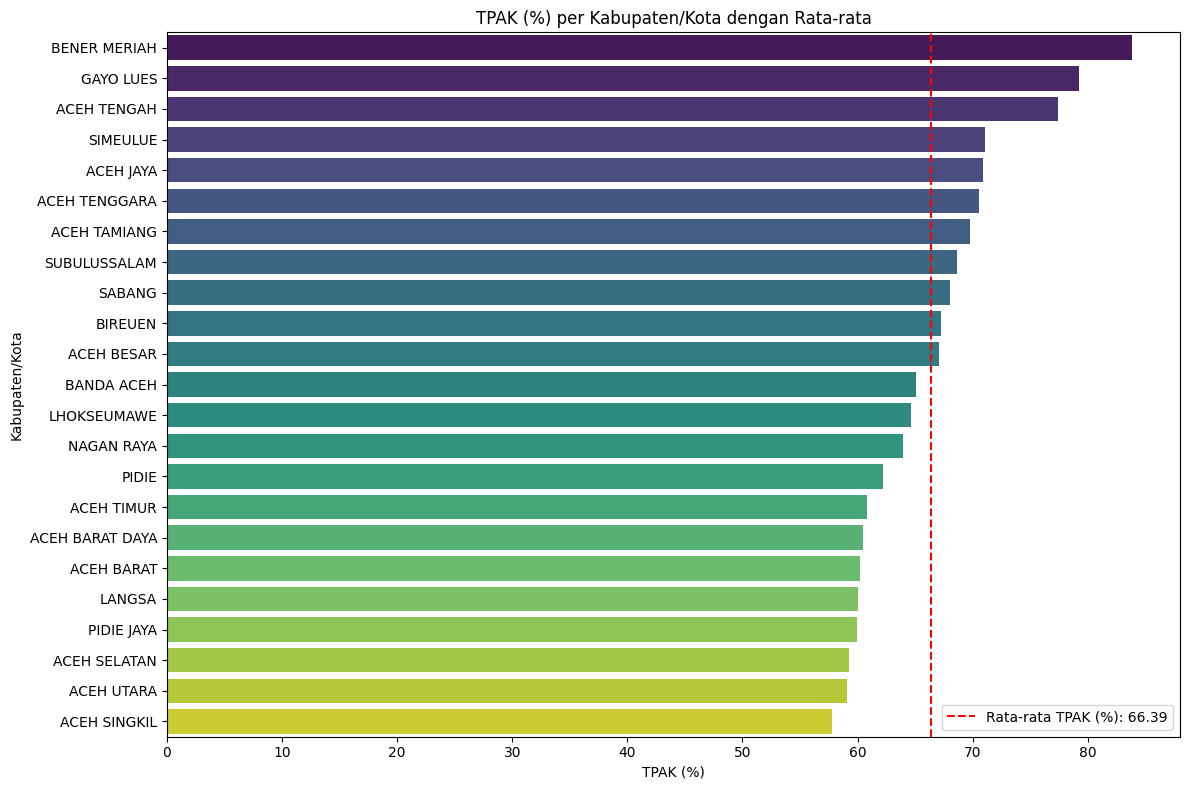

In [37]:
plt.figure(figsize=(12, 8))
data_sorted = data_mentah.sort_values('TPAK (%)', ascending=False)

sns.barplot(
    x='TPAK (%)',
    y='Kabupaten/Kota',
    data=data_sorted,
    hue='Kabupaten/Kota',
    palette='viridis',
    legend=False
)

mean_pdrb = data_mentah['TPAK (%)'].mean()


plt.axvline(x=mean_pdrb, color='red', linestyle='--', label=f'Rata-rata TPAK (%): {mean_pdrb:.2f}')

plt.xlabel('TPAK (%)')
plt.ylabel('Kabupaten/Kota')
plt.title('TPAK (%) per Kabupaten/Kota dengan Rata-rata')
plt.legend()
plt.tight_layout()
plt.show()

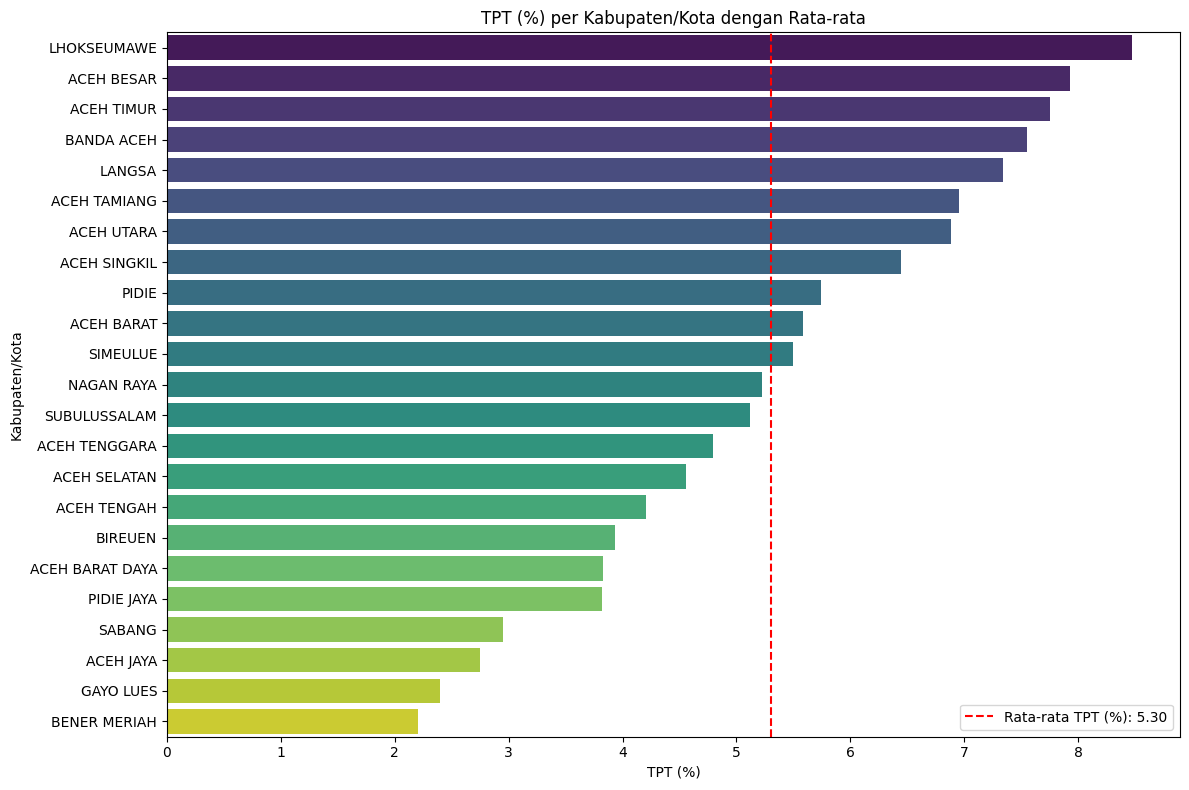

In [38]:
plt.figure(figsize=(12, 8))
data_sorted = data_mentah.sort_values('TPT (%)', ascending=False)

sns.barplot(
    x='TPT (%)',
    y='Kabupaten/Kota',
    data=data_sorted,
    hue='Kabupaten/Kota',
    palette='viridis',
    legend=False
)

mean_pdrb = data_mentah['TPT (%)'].mean()


plt.axvline(x=mean_pdrb, color='red', linestyle='--', label=f'Rata-rata TPT (%): {mean_pdrb:.2f}')

plt.xlabel('TPT (%)')
plt.ylabel('Kabupaten/Kota')
plt.title('TPT (%) per Kabupaten/Kota dengan Rata-rata')
plt.legend()
plt.tight_layout()
plt.show()

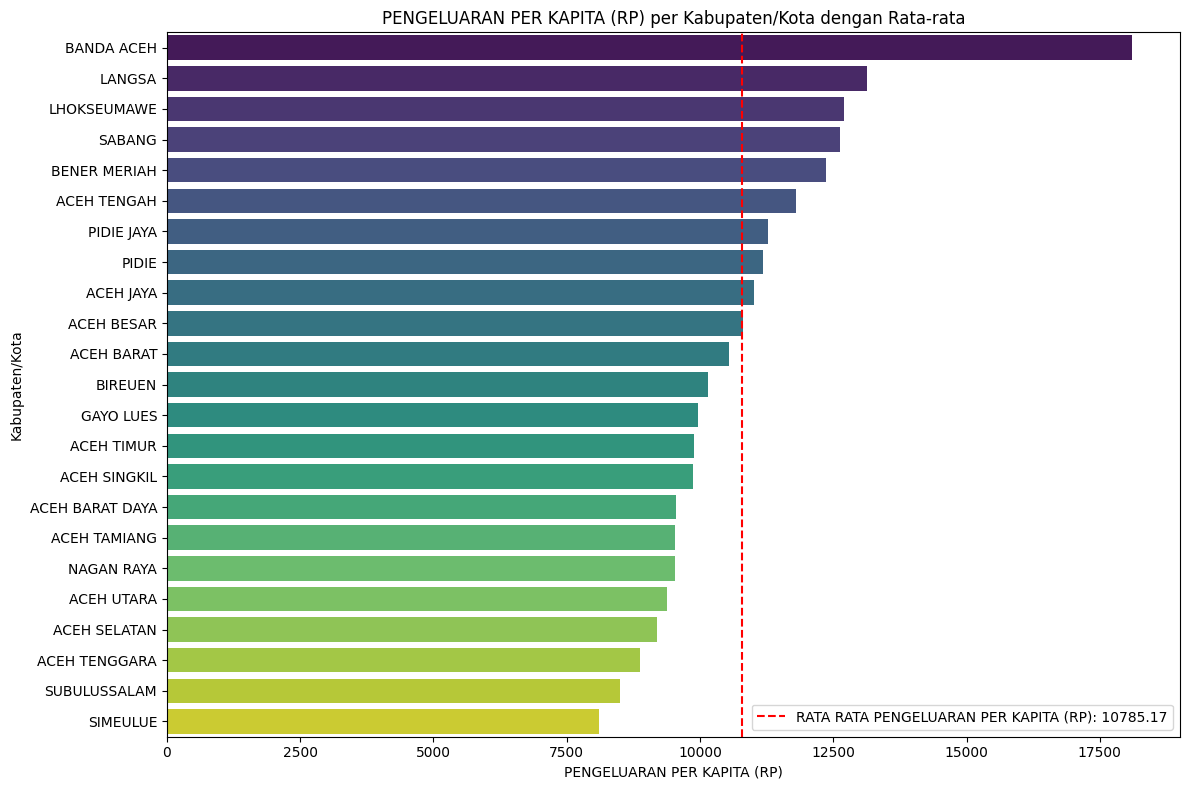

In [39]:
plt.figure(figsize=(12, 8))
data_sorted = data_mentah.sort_values('PENGELUARAN PER KAPITA (RP)', ascending=False)

sns.barplot(
    x='PENGELUARAN PER KAPITA (RP)',
    y='Kabupaten/Kota',
    data=data_sorted,
    hue='Kabupaten/Kota',
    palette='viridis',
    legend=False
)

mean_pdrb = data_mentah['PENGELUARAN PER KAPITA (RP)'].mean()


plt.axvline(x=mean_pdrb, color='red', linestyle='--', label=f'RATA RATA PENGELUARAN PER KAPITA (RP): {mean_pdrb:.2f}')

plt.xlabel('PENGELUARAN PER KAPITA (RP)')
plt.ylabel('Kabupaten/Kota')
plt.title('PENGELUARAN PER KAPITA (RP) per Kabupaten/Kota dengan Rata-rata')
plt.legend()
plt.tight_layout()
plt.show()

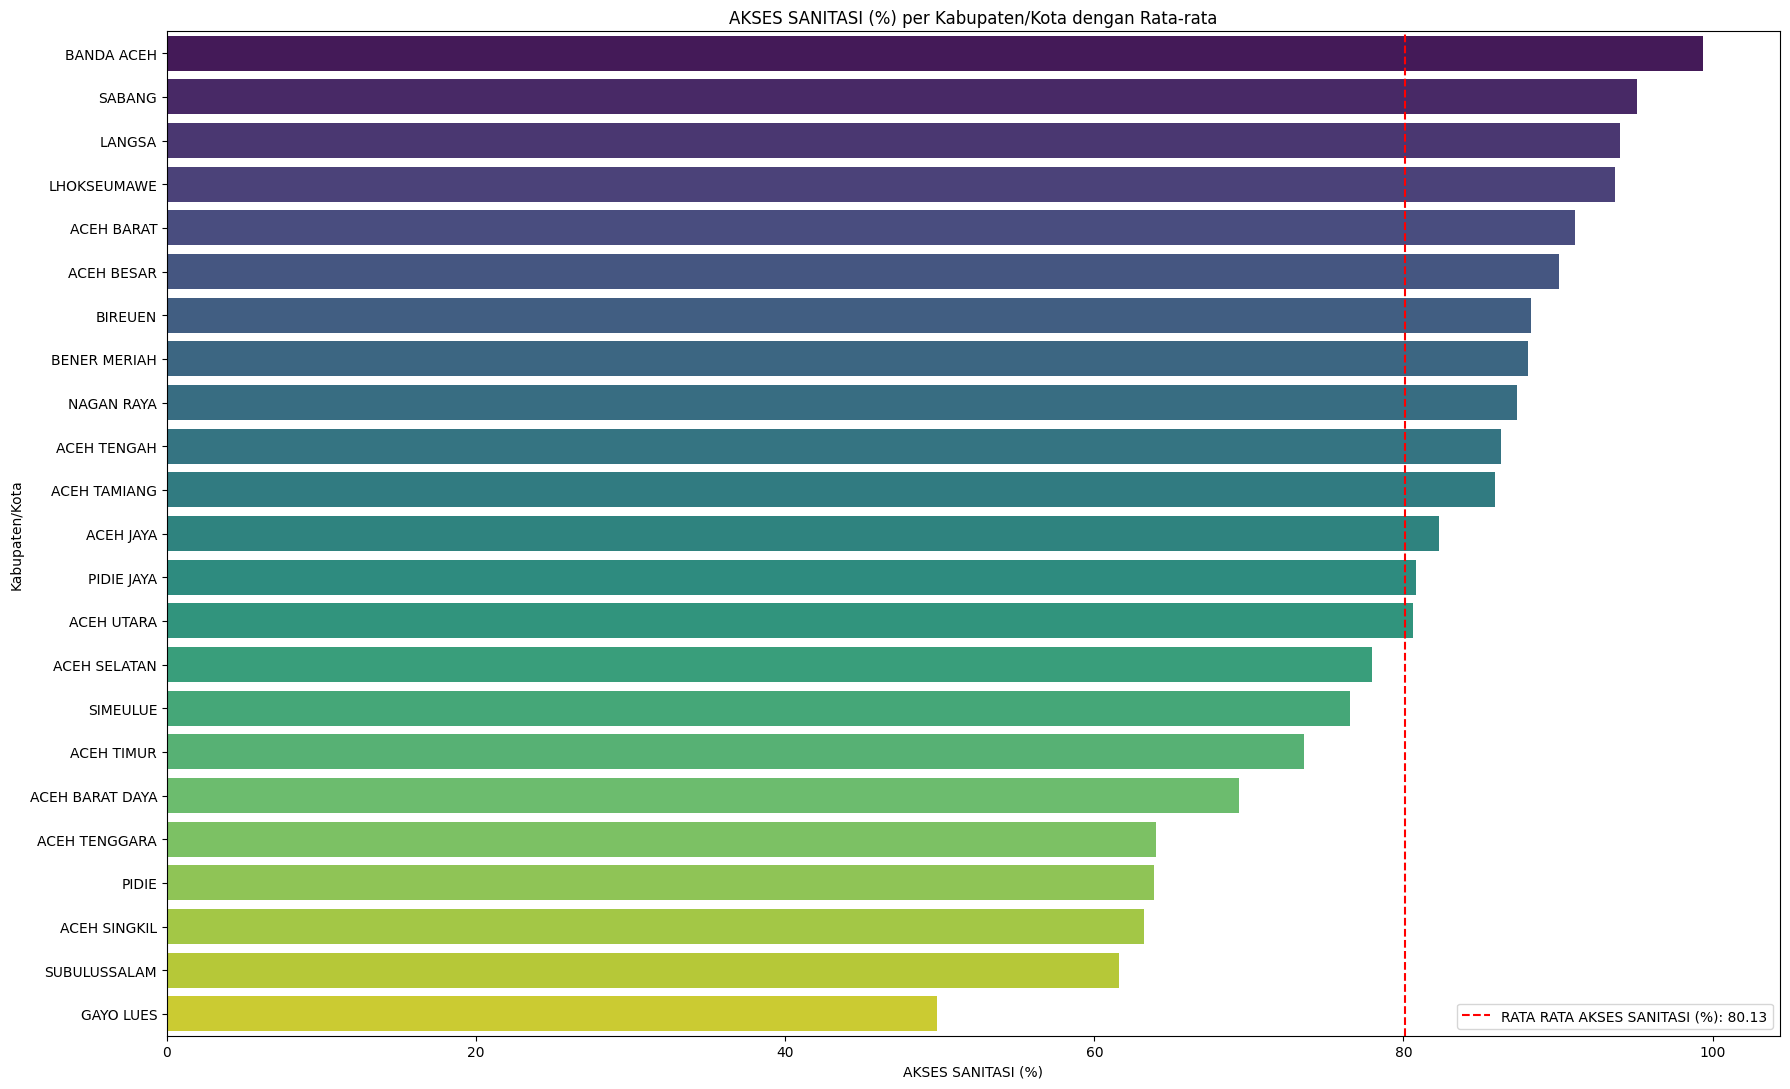

In [40]:
plt.figure(figsize=(18, 11))
data_sorted = data_mentah.sort_values('AKSES SANITASI (%)', ascending=False)

sns.barplot(
    x='AKSES SANITASI (%)',
    y='Kabupaten/Kota',
    data=data_sorted,
    hue='Kabupaten/Kota',
    palette='viridis',
    legend=False
)

mean_pdrb = data_mentah['AKSES SANITASI (%)'].mean()


plt.axvline(x=mean_pdrb, color='red', linestyle='--', label=f'RATA RATA AKSES SANITASI (%): {mean_pdrb:.2f}')

plt.xlabel('AKSES SANITASI (%)')
plt.ylabel('Kabupaten/Kota')
plt.title('AKSES SANITASI (%) per Kabupaten/Kota dengan Rata-rata')
plt.legend()
plt.tight_layout()
plt.show()

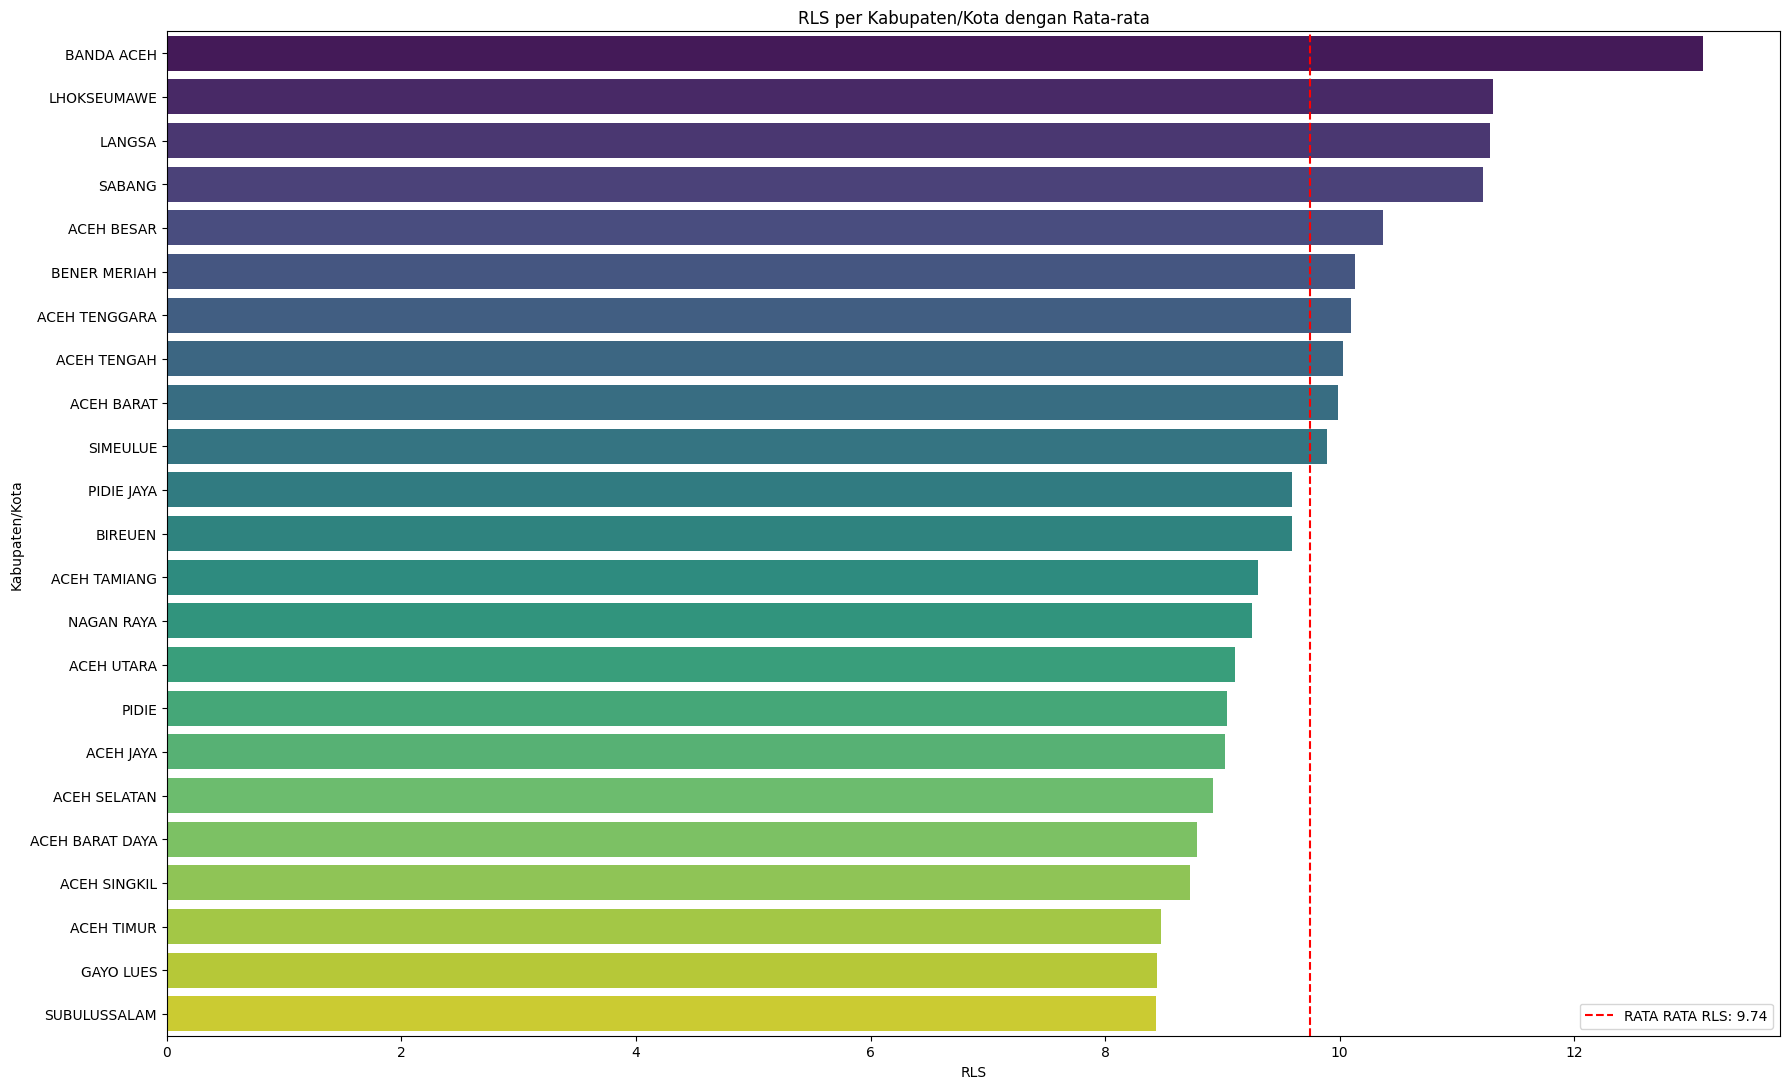

In [41]:
plt.figure(figsize=(18, 11))
data_sorted = data_mentah.sort_values('RLS', ascending=False)

sns.barplot(
    x='RLS',
    y='Kabupaten/Kota',
    data=data_sorted,
    hue='Kabupaten/Kota',
    palette='viridis',
    legend=False
)

mean_pdrb = data_mentah['RLS'].mean()


plt.axvline(x=mean_pdrb, color='red', linestyle='--', label=f'RATA RATA RLS: {mean_pdrb:.2f}')

plt.xlabel('RLS')
plt.ylabel('Kabupaten/Kota')
plt.title('RLS per Kabupaten/Kota dengan Rata-rata')
plt.legend()
plt.tight_layout()
plt.show()

# KNN

In [42]:
# RENTAN = 0, AMAN = 1
mapping = {'AMAN': 1, 'RENTAN': 0}

# Terapkan pada kolom
data_mentah['LABEL'] = data_mentah['LABEL'].map(mapping)

# PISAH X DAN Y
x = data_mentah[['PDRB','RLS','AKSES SANITASI (%)','PENGELUARAN PER KAPITA (RP)','TPT (%)','TPAK (%)']]
y = data_mentah['LABEL']

In [43]:
y

,LABEL
0,0
1,1
2,0
3,0
4,0
5,1
6,1
7,0
8,1
9,0


In [44]:
x

,PDRB,RLS,AKSES SANITASI (%),PENGELUARAN PER KAPITA (RP),TPT (%),TPAK (%)
0,3150,9.89,76.51,8106,5.50,71.08
1,3441,8.72,63.22,9862,6.44,57.82
2,7466,8.92,77.96,9190,4.56,59.24
3,6737,10.10,64.01,8876,4.79,70.51
4,14935,8.48,73.59,9889,7.75,60.84
5,10721,10.03,86.34,11805,4.21,77.41
6,14050,9.99,91.09,10548,5.58,60.23
7,18412,10.37,90.03,10810,7.93,67.05
8,14549,9.04,63.88,11187,5.74,62.17
9,18330,9.59,88.26,10150,3.93,67.24


In [45]:
# BAGI DATA TRAINING DAN TESTING DENGAN PERBADINGAN 8:2
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.10, random_state=42)

In [46]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(20, 6)
(3, 6)
(20,)
(3,)


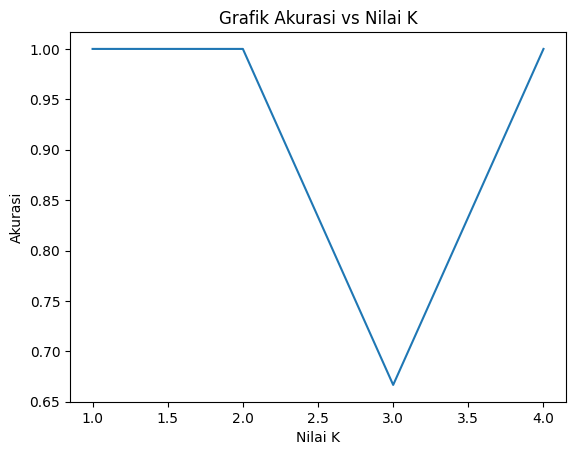

In [47]:
# LOOP CARI K OPTIMUM
nilai_k = list(range(1, 5))
score = []

for k in nilai_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    score.append(accuracy_score(y_test, y_pred))

plt.plot(nilai_k, score)
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.title('Grafik Akurasi vs Nilai K')
plt.show()


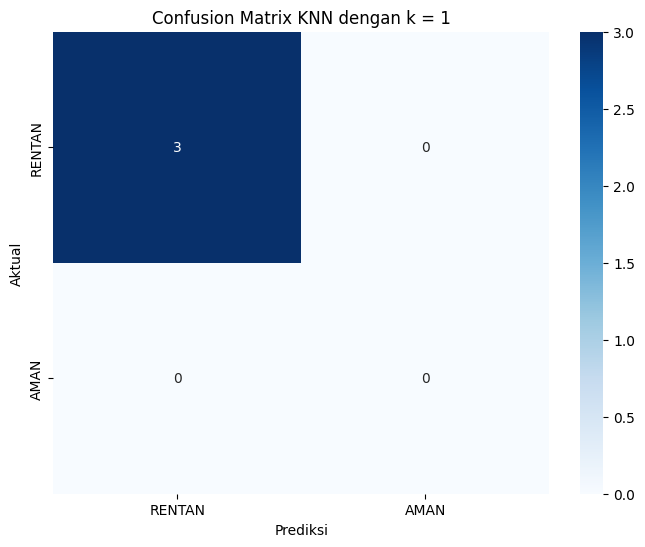

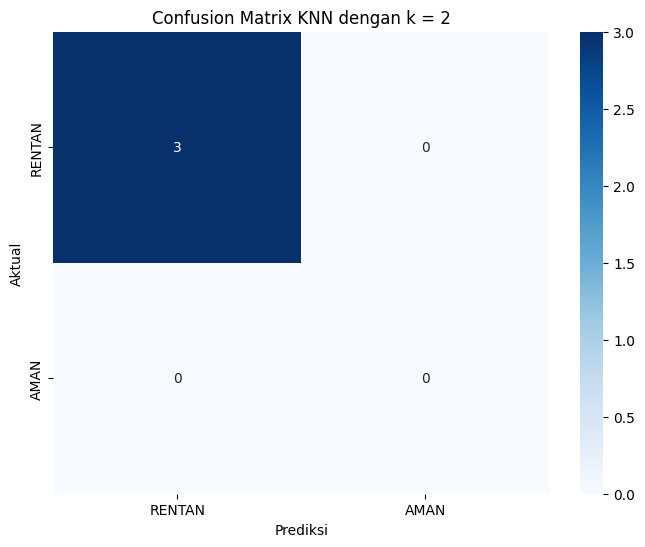

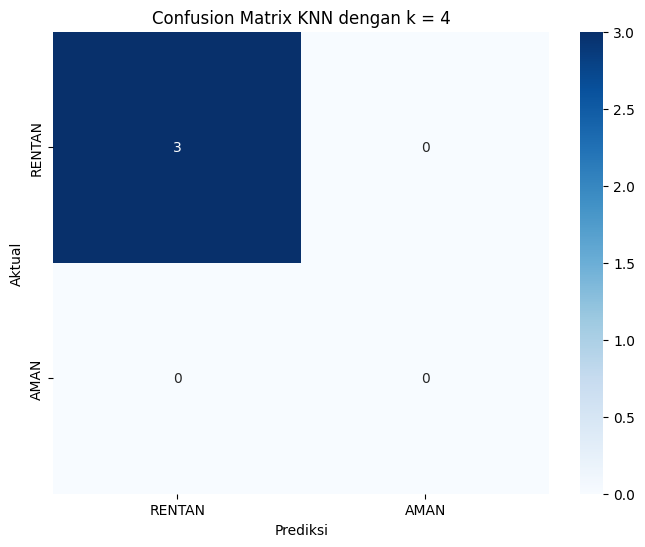

In [48]:
# CONFUSION MATRIX DENGAN K = 1
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['RENTAN', 'AMAN'], yticklabels=['RENTAN', 'AMAN'])
plt.title('Confusion Matrix KNN dengan k = 1')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


# CONFUSION MATRIX DENGAN K = 2
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['RENTAN', 'AMAN'], yticklabels=['RENTAN', 'AMAN'])
plt.title('Confusion Matrix KNN dengan k = 2')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


# CONFUSION MATRIX DENGAN K = 4
knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['RENTAN', 'AMAN'], yticklabels=['RENTAN', 'AMAN'])
plt.title('Confusion Matrix KNN dengan k = 4')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Memulai proses pencarian parameter dan pembuatan grafik...

=== Hasil Optimal yang Ditemukan ===
Akurasi Maksimal : 100.00%
Test Size Terbaik: 0.1
Nilai K Terbaik  : 1



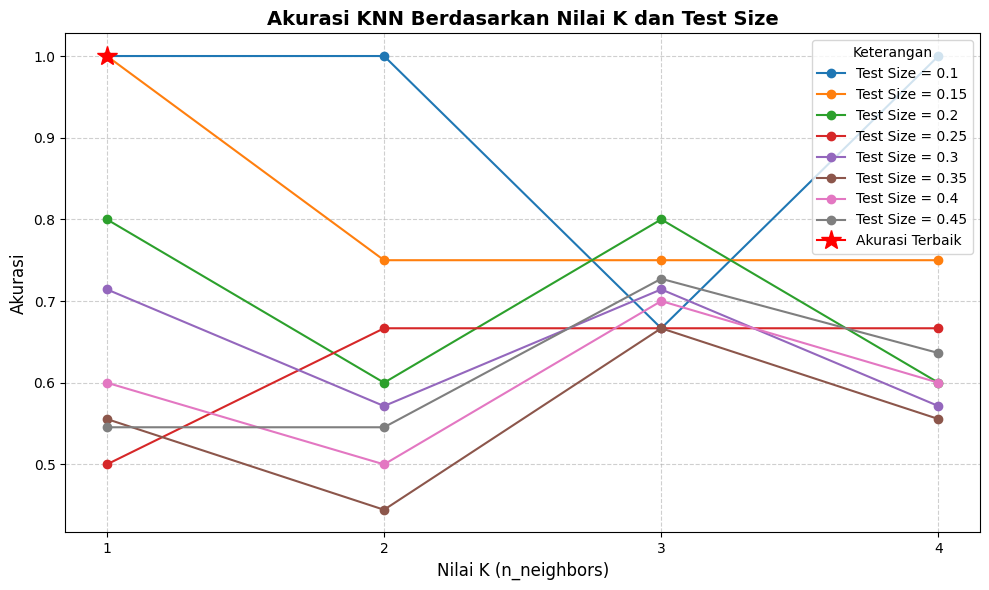

In [49]:
# PISAH X DAN Y
x = data_mentah[['PDRB','RLS','AKSES SANITASI (%)','PENGELUARAN PER KAPITA (RP)','TPT (%)','TPAK (%)']]
y = data_mentah['LABEL']

# 2. Menentukan rentang test_size dan K
# Saya menggunakan 4 variasi test size agar grafik lebih mudah dibaca dan tidak terlalu menumpuk
test_sizes = [0.10,0.15,0.20,0.25, 0.30,0.35, 0.40,0.45]
k_values = range(1, 5)

# Dictionary untuk menyimpan riwayat akurasi untuk keperluan grafik
accuracy_results = {ts: [] for ts in test_sizes}

best_accuracy = 0
best_k = 0
best_test_size = 0

print("Memulai proses pencarian parameter dan pembuatan grafik...\n")

# 3. Looping test_size dan K
for ts in test_sizes:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts, random_state=42)

    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(x_train, y_train)
        y_pred = knn.predict(x_test)

        accuracy = accuracy_score(y_test, y_pred)

        # Menyimpan nilai akurasi ke dalam dictionary untuk di-plot nanti
        accuracy_results[ts].append(accuracy)

        # Memperbarui nilai terbaik
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k
            best_test_size = ts

# 4. Menampilkan hasil di terminal/console
print("=== Hasil Optimal yang Ditemukan ===")
print(f"Akurasi Maksimal : {best_accuracy * 100:.2f}%")
print(f"Test Size Terbaik: {best_test_size}")
print(f"Nilai K Terbaik  : {best_k}\n")

# 5. Membuat Visualisasi Grafik
plt.figure(figsize=(10, 6))

# Looping untuk membuat garis plot untuk masing-masing test_size
for ts in test_sizes:
    plt.plot(list(k_values), accuracy_results[ts], marker='o', label=f'Test Size = {ts}')

# Pengaturan tata letak grafik
plt.title('Akurasi KNN Berdasarkan Nilai K dan Test Size', fontsize=14, fontweight='bold')
plt.xlabel('Nilai K (n_neighbors)', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)
plt.xticks(list(k_values)) # Menampilkan semua angka 1-20 di sumbu X
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Proporsi Test Size')

# Menandai titik akurasi terbaik di grafik
plt.plot(best_k, best_accuracy, marker='*', markersize=15, color='red', label='Akurasi Terbaik')
plt.legend(title='Keterangan')

plt.tight_layout()
plt.show() # Menampilkan grafik

# DECISION TREE

In [50]:
data_mentah.head()

,Kabupaten/Kota,GARIS KEMISKINAN (RP),IPM,RLS,INDEKS KEDALAMAN KEMISKINAN,LABEL,AKSES SANITASI (%),PENGELUARAN PER KAPITA (RP),TPT (%),TPAK (%),PDRB
0,SIMEULUE,576505,69.01,9.89,2.62,0,76.51,8106,5.50,71.08,3150
1,ACEH SINGKIL,609322,70.75,8.72,3.06,1,63.22,9862,6.44,57.82,3441
2,ACEH SELATAN,528243,69.10,8.92,1.57,0,77.96,9190,4.56,59.24,7466
3,ACEH TENGGARA,496074,71.70,10.10,1.64,0,64.01,8876,4.79,70.51,6737
4,ACEH TIMUR,557943,69.87,8.48,2.04,0,73.59,9889,7.75,60.84,14935


In [51]:
# PISAH X DAN Y
x = data_mentah[['PDRB','RLS','AKSES SANITASI (%)','PENGELUARAN PER KAPITA (RP)','TPT (%)','TPAK (%)']]
y = data_mentah['LABEL']

In [52]:
x

,PDRB,RLS,AKSES SANITASI (%),PENGELUARAN PER KAPITA (RP),TPT (%),TPAK (%)
0,3150,9.89,76.51,8106,5.50,71.08
1,3441,8.72,63.22,9862,6.44,57.82
2,7466,8.92,77.96,9190,4.56,59.24
3,6737,10.10,64.01,8876,4.79,70.51
4,14935,8.48,73.59,9889,7.75,60.84
5,10721,10.03,86.34,11805,4.21,77.41
6,14050,9.99,91.09,10548,5.58,60.23
7,18412,10.37,90.03,10810,7.93,67.05
8,14549,9.04,63.88,11187,5.74,62.17
9,18330,9.59,88.26,10150,3.93,67.24


In [53]:
y

,LABEL
0,0
1,1
2,0
3,0
4,0
5,1
6,1
7,0
8,1
9,0


In [54]:
# BAGI DATA TRAINING DAN TESTING DENGAN PERBANDINGAN 6:4
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

In [55]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(19, 6)
(4, 6)
(19,)
(4,)


In [56]:
# LATIH MODEL
model_decisiontree = DecisionTreeClassifier(criterion='entropy', random_state=42) # ENTROPY = C4.6
model_decisiontree.fit(x_train, y_train)

y_pred = model_decisiontree.predict(x_test)
print("akurasi:", accuracy_score(y_test, y_pred)*100)

print(classification_report(y_test, y_pred))

akurasi: 75.0
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



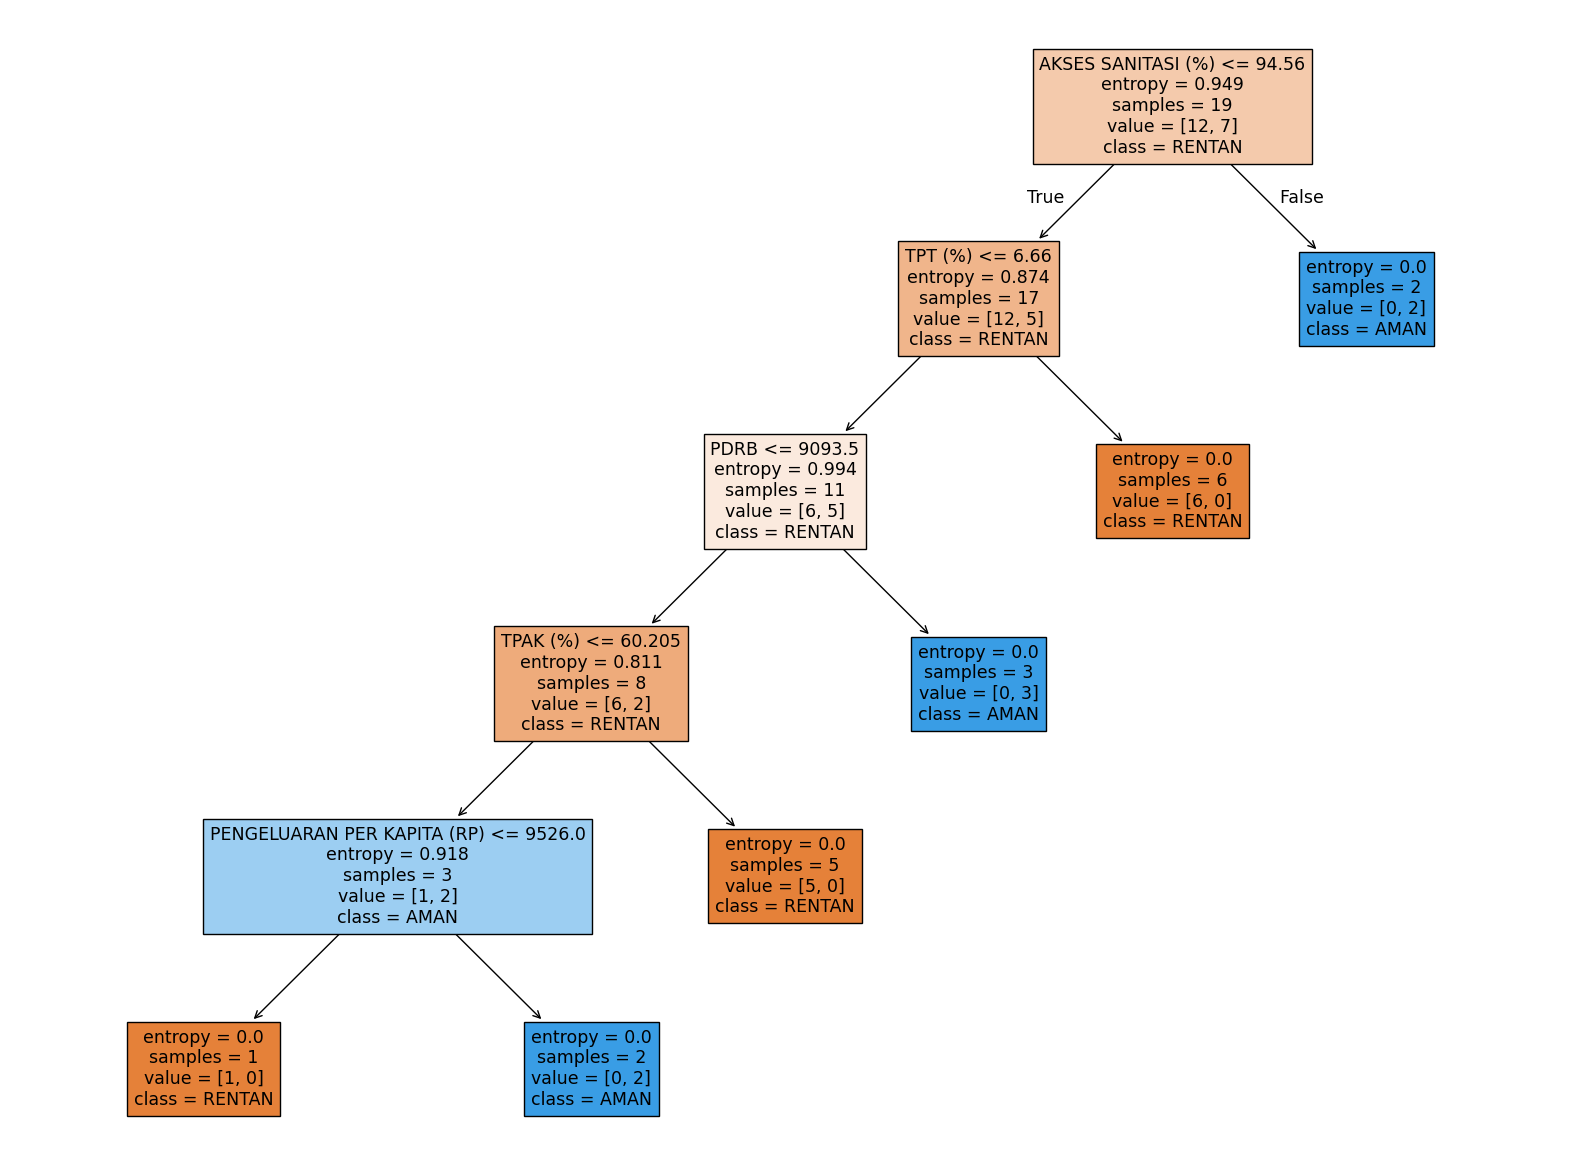

In [57]:
# VISUALISASI DECISION TREE
plt.figure(figsize=(20, 15)) # Mengatur ukuran visualisasi agar lebih besar
plot_tree(model_decisiontree, filled=True, feature_names=x.columns, class_names=['RENTAN', 'AMAN'])
plt.show()

akurasi: 75.0
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4


Fitur Terpilih:
                       Feature  Importance
0                         PDRB    0.246353
4                      TPT (%)    0.217485
5                     TPAK (%)    0.207063
2           AKSES SANITASI (%)    0.176385
3  PENGELUARAN PER KAPITA (RP)    0.152713


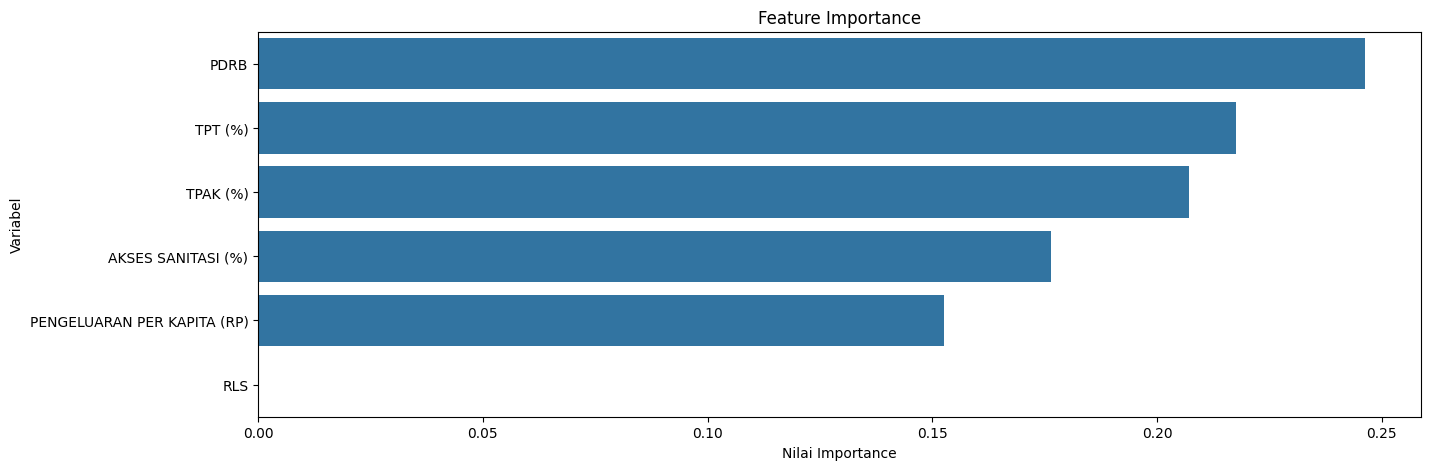

In [58]:
# PISAH X DAN Y
x = data_mentah[['PDRB','RLS','AKSES SANITASI (%)','PENGELUARAN PER KAPITA (RP)','TPT (%)','TPAK (%)']]
y = data_mentah['LABEL']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

model_decisiontree = DecisionTreeClassifier(criterion='entropy', random_state=42) # ENTROPY = C4.6, CART = gini
model_decisiontree.fit(x_train, y_train)

y_pred = model_decisiontree.predict(x_test)
print("akurasi:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred))

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model_decisiontree.feature_importances_
}).sort_values(by='Importance', ascending=False)

selected_features = feature_importance[
    feature_importance['Importance'] > 0  # Select features with importance greater than 0
]

print("\nFitur Terpilih:")
print(selected_features)

# Feature Importance
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model_decisiontree.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(15,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.xlabel("Nilai Importance")
plt.ylabel("Variabel")
plt.show()

**CATATAN DARI PAK RIEFKY**

*   pemilihan variabel kurang pas ( disesuaikan dengan teorinya)
*   cari variabel lain yang benar2 memengaruhi dan bisa berkontribusi
*   C4.5,CART
*   PARTISI DI COBA YANG LAIN



--- Testing with test_size = 0.10 ---
Decision Tree Accuracy for test_size 0.10: 66.67%

--- Testing with test_size = 0.15 ---
Decision Tree Accuracy for test_size 0.15: 75.00%

--- Testing with test_size = 0.20 ---
Decision Tree Accuracy for test_size 0.20: 60.00%

--- Testing with test_size = 0.25 ---
Decision Tree Accuracy for test_size 0.25: 66.67%

--- Testing with test_size = 0.30 ---
Decision Tree Accuracy for test_size 0.30: 42.86%

--- Testing with test_size = 0.35 ---
Decision Tree Accuracy for test_size 0.35: 55.56%

--- Testing with test_size = 0.40 ---
Decision Tree Accuracy for test_size 0.40: 60.00%

--- Testing with test_size = 0.45 ---
Decision Tree Accuracy for test_size 0.45: 63.64%


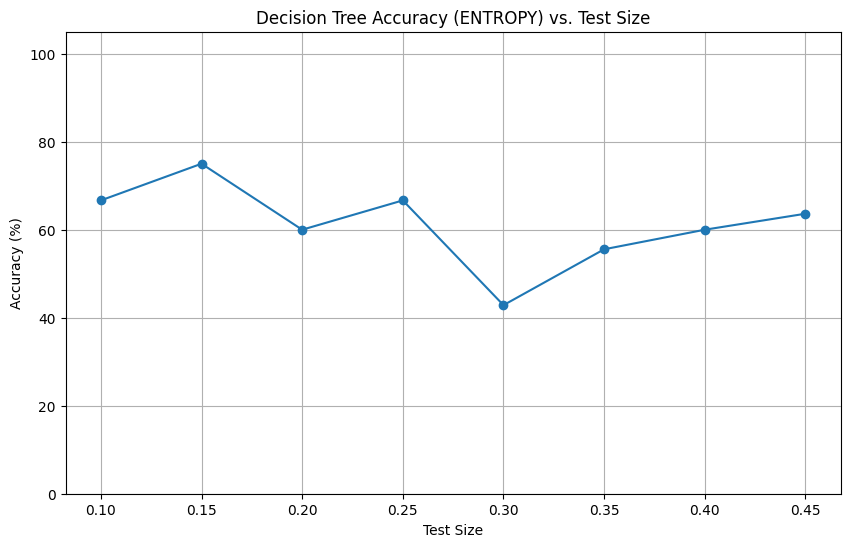


--- Testing with test_size = 0.10 ---
Decision Tree Accuracy for test_size 0.10: 33.33%

--- Testing with test_size = 0.15 ---
Decision Tree Accuracy for test_size 0.15: 75.00%

--- Testing with test_size = 0.20 ---
Decision Tree Accuracy for test_size 0.20: 40.00%

--- Testing with test_size = 0.25 ---
Decision Tree Accuracy for test_size 0.25: 66.67%

--- Testing with test_size = 0.30 ---
Decision Tree Accuracy for test_size 0.30: 42.86%

--- Testing with test_size = 0.35 ---
Decision Tree Accuracy for test_size 0.35: 55.56%

--- Testing with test_size = 0.40 ---
Decision Tree Accuracy for test_size 0.40: 60.00%

--- Testing with test_size = 0.45 ---
Decision Tree Accuracy for test_size 0.45: 63.64%


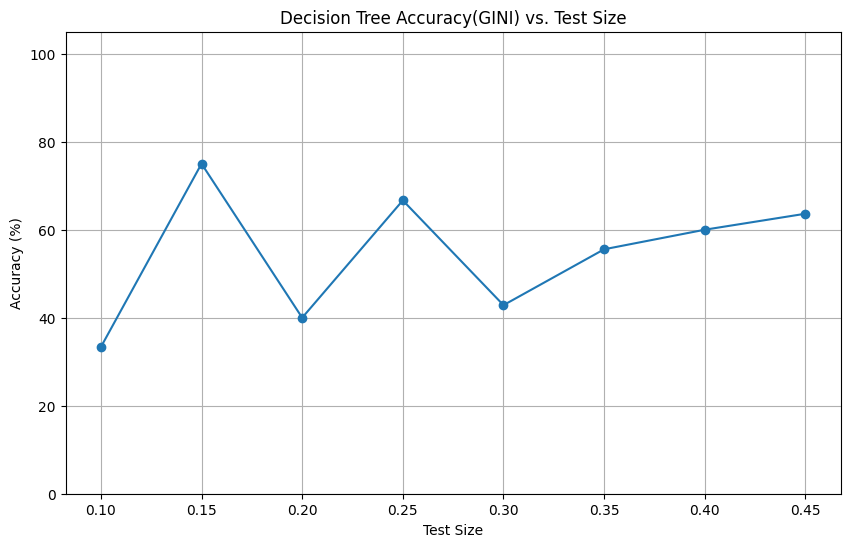


--- Testing with test_size = 0.10 ---
Decision Tree Accuracy for test_size 0.10: 66.67%

--- Testing with test_size = 0.15 ---
Decision Tree Accuracy for test_size 0.15: 75.00%

--- Testing with test_size = 0.20 ---
Decision Tree Accuracy for test_size 0.20: 60.00%

--- Testing with test_size = 0.25 ---
Decision Tree Accuracy for test_size 0.25: 66.67%

--- Testing with test_size = 0.30 ---
Decision Tree Accuracy for test_size 0.30: 42.86%

--- Testing with test_size = 0.35 ---
Decision Tree Accuracy for test_size 0.35: 55.56%

--- Testing with test_size = 0.40 ---
Decision Tree Accuracy for test_size 0.40: 60.00%

--- Testing with test_size = 0.45 ---
Decision Tree Accuracy for test_size 0.45: 63.64%


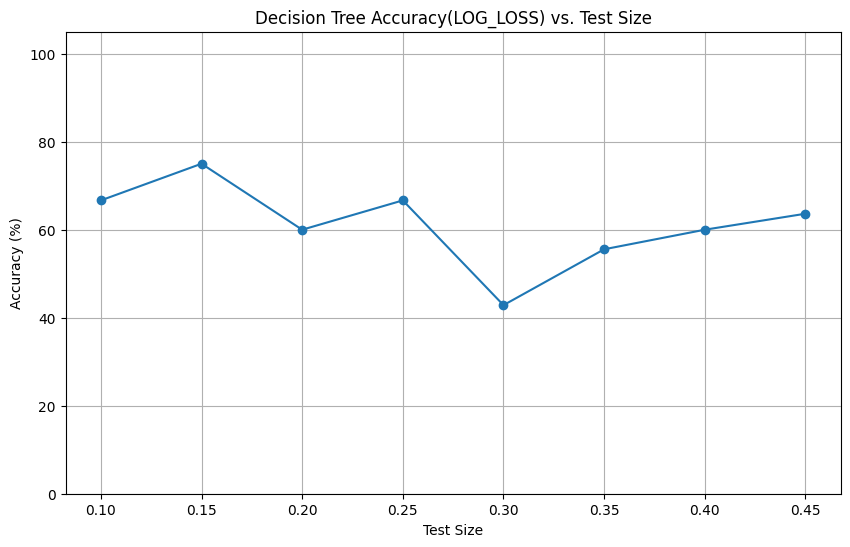

In [59]:
# LOOP PARTISI DARI 0.1 - 0.45 DENGAN C4.5
test_sizes = [0.10,0.15,0.20,0.25, 0.30,0.35, 0.40,0.45]

accuracy_scores_dt = []

for test_size in test_sizes:
    print(f"\n--- Testing with test_size = {test_size:.2f} ---")
    x_train_loop, x_test_loop, y_train_loop, y_test_loop = train_test_split(x, y, test_size=test_size, random_state=42)

    # Train the Decision Tree model
    model_decisiontree_loop = DecisionTreeClassifier(criterion='entropy', random_state=42,max_depth=5)
    model_decisiontree_loop.fit(x_train_loop, y_train_loop)

    # Make predictions and calculate accuracy
    y_pred_loop = model_decisiontree_loop.predict(x_test_loop)
    accuracy_loop = accuracy_score(y_test_loop, y_pred_loop) * 100
    accuracy_scores_dt.append(accuracy_loop)

    print(f"Decision Tree Accuracy for test_size {test_size:.2f}: {accuracy_loop:.2f}%")
    # print(classification_report(y_test_loop, y_pred_loop))

plt.figure(figsize=(10, 6))
plt.plot(test_sizes, accuracy_scores_dt, marker='o', linestyle='-')
plt.title('Decision Tree Accuracy (ENTROPY) vs. Test Size')
plt.xlabel('Test Size')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.xticks(test_sizes)
plt.ylim(0, 105)
plt.show()


# # LOOP PARTISI DARI 0.1 - 0.45 DENGAN GINI/CART
accuracy_scores_dt = []

for test_size in test_sizes:
    print(f"\n--- Testing with test_size = {test_size:.2f} ---")
    x_train_loop, x_test_loop, y_train_loop, y_test_loop = train_test_split(x, y, test_size=test_size, random_state=42)

    # Train the Decision Tree model
    model_decisiontree_loop = DecisionTreeClassifier(criterion='gini', random_state=42,max_depth=5)
    model_decisiontree_loop.fit(x_train_loop, y_train_loop)

    # Make predictions and calculate accuracy
    y_pred_loop = model_decisiontree_loop.predict(x_test_loop)
    accuracy_loop = accuracy_score(y_test_loop, y_pred_loop) * 100
    accuracy_scores_dt.append(accuracy_loop)

    print(f"Decision Tree Accuracy for test_size {test_size:.2f}: {accuracy_loop:.2f}%")
    # print(classification_report(y_test_loop, y_pred_loop))

plt.figure(figsize=(10, 6))
plt.plot(test_sizes, accuracy_scores_dt, marker='o', linestyle='-')
plt.title('Decision Tree Accuracy(GINI) vs. Test Size')
plt.xlabel('Test Size')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.xticks(test_sizes)
plt.ylim(0, 105)
plt.show()


# LOOP PARTISI DARI 0.1 - 0.45 DENGAN LOG_LOSS
test_sizes = np.arange(0.1, 0.5, 0.05)

accuracy_scores_dt = []

for test_size in test_sizes:
    print(f"\n--- Testing with test_size = {test_size:.2f} ---")
    x_train_loop, x_test_loop, y_train_loop, y_test_loop = train_test_split(x, y, test_size=test_size, random_state=42)

    # Train the Decision Tree model
    model_decisiontree_loop = DecisionTreeClassifier(criterion='log_loss', random_state=42,max_depth=5)
    model_decisiontree_loop.fit(x_train_loop, y_train_loop)

    # Make predictions and calculate accuracy
    y_pred_loop = model_decisiontree_loop.predict(x_test_loop)
    accuracy_loop = accuracy_score(y_test_loop, y_pred_loop) * 100
    accuracy_scores_dt.append(accuracy_loop)

    print(f"Decision Tree Accuracy for test_size {test_size:.2f}: {accuracy_loop:.2f}%")
    # print(classification_report(y_test_loop, y_pred_loop))

plt.figure(figsize=(10, 6))
plt.plot(test_sizes, accuracy_scores_dt, marker='o', linestyle='-')
plt.title('Decision Tree Accuracy(LOG_LOSS) vs. Test Size')
plt.xlabel('Test Size')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.xticks(test_sizes)
plt.ylim(0, 105)
plt.show()

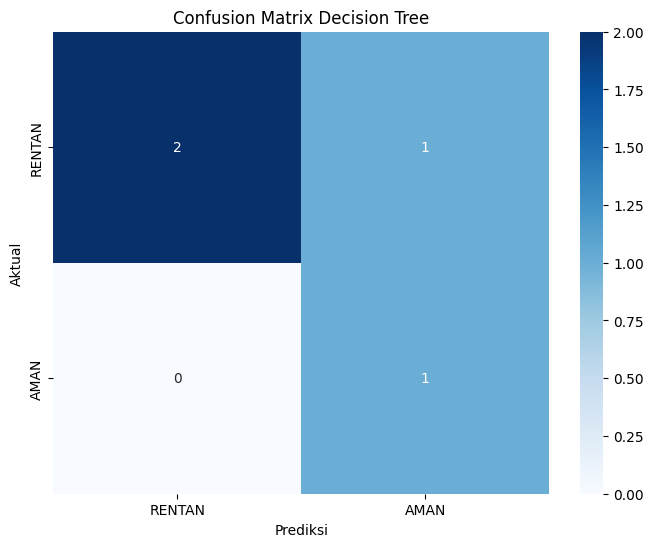

In [60]:
# convusion matrix decision tree
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['RENTAN', 'AMAN'], yticklabels=['RENTAN', 'AMAN'])
plt.title('Confusion Matrix Decision Tree')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()